Dataset Sample Counts:
ASDiv: 2305 samples
ParaMAWPS: 13023 samples
SVAMP: 1000 samples
DMath: 7943 samples
AQuA: 97467 samples
Total samples across all datasets: 121738


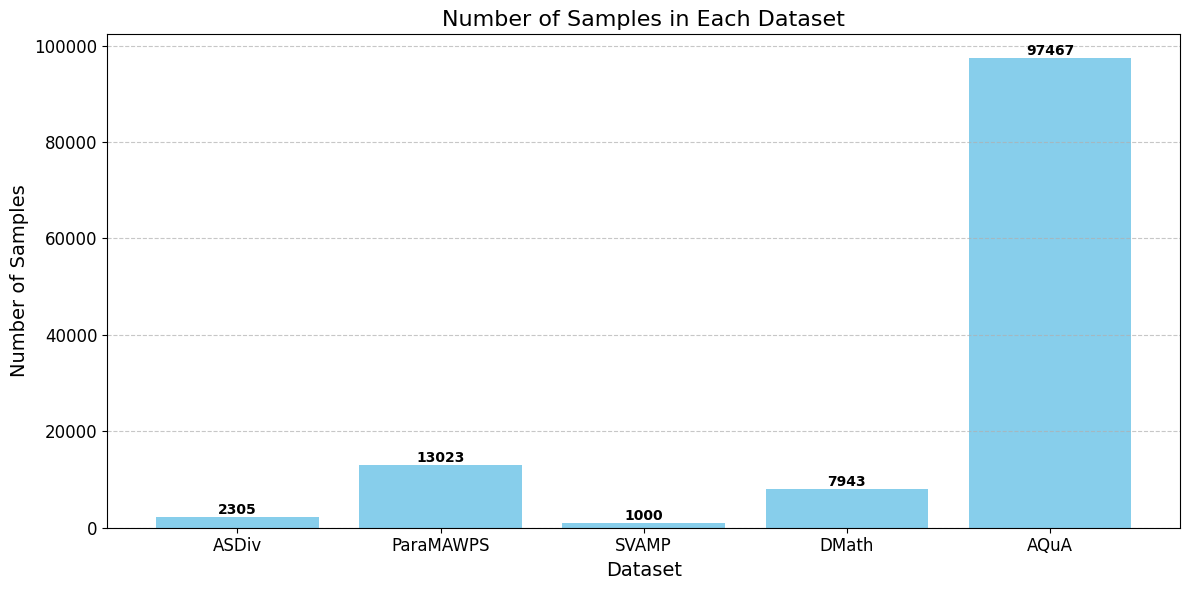

In [5]:
import os
import json
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import pandas as pd


# Define the paths
data_paths = [
    "/Users/jonathan/Library/Mobile Documents/com~apple~CloudDocs/Master/Master Thesis/math-reasoning-in-language-models/data/curriculum_learning/1_ASDiv/ASDiv.xml",
    "/Users/jonathan/Library/Mobile Documents/com~apple~CloudDocs/Master/Master Thesis/math-reasoning-in-language-models/data/curriculum_learning/2_ParaMAWPS/ParaMAWPS_trainset.json",
    "/Users/jonathan/Library/Mobile Documents/com~apple~CloudDocs/Master/Master Thesis/math-reasoning-in-language-models/data/curriculum_learning/3_SVAMP/SVAMP.json",
    "/Users/jonathan/Library/Mobile Documents/com~apple~CloudDocs/Master/Master Thesis/math-reasoning-in-language-models/data/curriculum_learning/4_Dmath/dmath_train.json",
    "/Users/jonathan/Library/Mobile Documents/com~apple~CloudDocs/Master/Master Thesis/math-reasoning-in-language-models/data/curriculum_learning/5_AQuA/AQuA_train.json"
]

# Dataset names
dataset_names = ["ASDiv", "ParaMAWPS", "SVAMP", "DMath", "AQuA"]

# Function to count samples in each dataset
def count_samples():
    counts = []
    
    # ASDiv (XML format)
    tree = ET.parse(data_paths[0])
    root = tree.getroot()
    asdiv_count = len(root.findall(".//Problem"))
    counts.append(asdiv_count)
    
    # ParaMAWPS (JSON format)
    with open(data_paths[1], 'r') as f:
        paramawps_data = json.load(f)
    counts.append(len(paramawps_data))
    
    # SVAMP (JSON format)
    with open(data_paths[2], 'r') as f:
        svamp_data = json.load(f)
    counts.append(len(svamp_data))
    
    # DMath (JSON format)
    with open(data_paths[3], 'r') as f:
        dmath_data = json.load(f)
    counts.append(len(dmath_data))
    
    # AQuA (JSON format)
    with open(data_paths[4], 'r') as f:
        aqua_data = [json.loads(line) for line in f]
    counts.append(len(aqua_data))
    
    return counts

# Count samples
sample_counts = count_samples()

# Create a bar chart
plt.figure(figsize=(12, 6))
bars = plt.bar(dataset_names, sample_counts, color='skyblue')

# Add data labels on top of each bar
for bar, count in zip(bars, sample_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             str(count), ha='center', va='bottom', fontweight='bold')

plt.title('Number of Samples in Each Dataset', fontsize=16)
plt.xlabel('Dataset', fontsize=14)
plt.ylabel('Number of Samples', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Save the figure
plt.tight_layout()

# Print the summary
print("Dataset Sample Counts:")
for name, count in zip(dataset_names, sample_counts):
    print(f"{name}: {count} samples")

print(f"Total samples across all datasets: {sum(sample_counts)}")

# Define your target directory - fix the path
save_dir = "/Users/jonathan/Library/Mobile Documents/com~apple~CloudDocs/Master/Master Thesis/math-reasoning-in-language-models/plots/plots_images"

# Create the directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Create the full file path
file_path = os.path.join(save_dir, "curriculum_learning_samples_distribution.png")

# Save the figure
plt.savefig(file_path, dpi=300, bbox_inches="tight")

plt.show()

# Optional: close the plot to free memory
plt.close()
